In [ ]:
"""
All the necessary libraries
pandas
numpy
sentence_transformers
sklearn.metrics.pairwise
sklearn.cluster
spacy
transformers
NetworkX
Matplotlib
"""

In [4]:
import pandas as pd
!pip install sentence-transformers
import numpy as np

In [5]:
#Load your CSV
df = pd.read_csv("/content/iran_israel_news_dataset.csv")
df1=df
#Basic cleaning
df = df.dropna(subset=["headline"])     #Remove rows where the headline column has missing value
df = df.drop_duplicates(subset=["headline"])    #Remove rows where the headline is repeated

#Convert date
df["date"] = pd.to_datetime(df["date"], errors="coerce")

df.reset_index(drop=True, inplace=True)

print("Dataset size:", len(df))
df.head()

Dataset size: 870


,headline,url,date,source,content,last_updated
0,Trump says US negotiating with Iran's parliame...,https://economictimes.indiatimes.com/news/inte...,2026-03-31 01:31:00+00:00,The Economic Times,US President Donald Trump on Monday threatened...,2026-03-31 14:28:41.235483
1,U.S.-Israel-Iran war puts India’s EV gap in focus,https://www.thehindu.com/data/us-israel-iran-w...,2026-03-31 01:30:00+00:00,The Hindu,The surge in global oil prices after the U.S.-...,2026-03-31 14:28:41.235483
2,Democratic lawmaker says US ‘badly and embarra...,https://www.moneycontrol.com/world/democratic-...,2026-03-31 01:26:05+00:00,Moneycontrol,"US senator Chris Murphy, a Democrat from Conne...",2026-03-31 14:28:41.235483
3,Iran-Israel war LIVE updates: Kuwait says Iran...,https://www.thehindu.com/news/international/us...,2026-03-31 01:13:44+00:00,The Hindu,U.S. President Donald Trump said on Tuesday (M...,2026-03-31 14:28:41.235483
4,Trump again threatens widespread destruction i...,https://www.ajc.com/news/2026/03/trump-again-t...,2026-03-31 01:01:13+00:00,The Atlanta Journal-Constitution,Trump again threatens widespread destruction i...,2026-03-31 14:28:41.235483


In [6]:
print(df.columns)

Index(['headline', 'url', 'date', 'source', 'content', 'last_updated'], dtype='object')


In [7]:
#Create text column
df["text"] = (
    df["headline"].fillna("") + " " +
    df["content"].fillna("")
)

#Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer     #Converts text to numerical vectors
from sklearn.metrics.pairwise import cosine_similarity          #Measures similarity between vectors

vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df["text"])             #Learns vocabulary

#Similarity
similarity_matrix = cosine_similarity(tfidf_matrix)

#Distance
distance_matrix = 1 - similarity_matrix

#Hierarchical Clustering (bottom-up)
from sklearn.cluster import AgglomerativeClustering

clustering = AgglomerativeClustering(
    n_clusters=None,                                                #Not fixing number of clusters
    metric='precomputed',
    linkage='average',
    distance_threshold=0.7
)

df["cluster"] = clustering.fit_predict(distance_matrix)

print("Number of clusters (events):", df["cluster"].nunique())

Number of clusters (events): 112


In [8]:
#Keep first article per cluster
representative_events = df.groupby("cluster").first().reset_index()

print("Reduced events:", len(representative_events))
representative_events.head()
cluster_sizes = df.groupby("cluster").size().reset_index(name="count")

#Merge back
events_ranked = representative_events.merge(cluster_sizes, on="cluster")

#Sort by importance
events_ranked = events_ranked.sort_values(by="count", ascending=False)

events_ranked.head(10)
for i, row in events_ranked.head(10).iterrows():
    print(f"\nEvent Cluster {row['cluster']} (Articles: {row['count']})")
    print("Headline:", row["headline"])
    print("Source:", row["source"])
    print("Date:", row["date"])

df["date_only"] = df["date"].dt.date

clusters_all = []

for date, group in df.groupby("date_only"):
    if len(group) < 2:
        group["cluster"] = -1
        clusters_all.append(group)
        continue

    X = vectorizer.fit_transform(group["headline"])
    sim = cosine_similarity(X)
    dist = 1 - sim

    clustering = AgglomerativeClustering(
        n_clusters=None,
        metric='precomputed',
        linkage='average',
        distance_threshold=0.7
    )

    group["cluster"] = clustering.fit_predict(dist)
    clusters_all.append(group)

df = pd.concat(clusters_all)

Reduced events: 112

Event Cluster 43 (Articles: 674)
Headline: US and Israel step up attacks as war with Iran engulfs region - Al Jazeera
Source: Google News
Date: NaT

Event Cluster 12 (Articles: 22)
Headline: Trump says US negotiating with Iran's parliamentary speaker Mohammad Bagher Qaliba, who denies talks
Source: The Economic Times
Date: 2026-03-31 01:31:00+00:00

Event Cluster 17 (Articles: 11)
Headline: 'Golden Pass LNG Project': QatarEnergy's Largest US Venture Records First Output, Exports To Begin In April-June
Source: NDTV Profit
Date: 2026-03-30 15:51:31+00:00

Event Cluster 3 (Articles: 6)
Headline: Tensions Escalate: Trump Threatens Iran's Energy Resources Amid Ongoing Conflict
Source: Devdiscourse
Date: 2026-03-30 14:16:09+00:00

Event Cluster 5 (Articles: 6)
Headline: Fire contained after missile attack on oil refinery in Israel’s Haifa
Source: Al Jazeera
Date: 2026-03-30 16:25:31+00:00

Event Cluster 6 (Articles: 5)
Headline: Petrol, diesel prices on 30 March: Check f

“Iran attacks Israel”
“Missile strike launched by Iran”

TF-IDF - may see them as different
Embeddings - understand they are similar

In [9]:
#Hugging Face Transformers
from sentence_transformers import SentenceTransformer
#Convert text into dense semantic vectors(embeddings)
model = SentenceTransformer('all-MiniLM-L6-v2')     #Sentence similarity, Semantic search, Clustering

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [10]:
df1 = df.dropna(subset=["headline"])
df1 = df.drop_duplicates(subset=["headline"])

df1["date"] = pd.to_datetime(df["date"], errors="coerce")
df1["date_only"] = df["date"].dt.date

df1.reset_index(drop=True, inplace=True)

print("Dataset size:", len(df1))

Dataset size: 196


In [11]:
#==============================
#Event Detection Pipeline
#==============================

import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.text import TfidfVectorizer

#Clean data
df = df1.copy()

df = df.dropna(subset=["headline"])
df = df.drop_duplicates(subset=["headline"])

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["date_only"] = df["date"].dt.date

df.reset_index(drop=True, inplace=True)

print("Dataset size:", len(df))


#Embedding
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(
    df["headline"].tolist(),
    show_progress_bar=True
)


#Clustering
similarity_matrix = cosine_similarity(embeddings)
distance_matrix = 1 - similarity_matrix

clustering = AgglomerativeClustering(
    n_clusters=None,
    metric='precomputed',
    linkage='average',
    distance_threshold=0.6
)

df["cluster"] = clustering.fit_predict(distance_matrix)

print("Total events detected:", df["cluster"].nunique())


#Event naming
#Extracts top keywords using TF-IDF uses them as event name
def generate_event_name(texts):
    vectorizer = TfidfVectorizer(stop_words='english', max_features=5)
    X = vectorizer.fit_transform(texts)
    keywords = vectorizer.get_feature_names_out()
    return " ".join(keywords[:3])

event_names = {}

for cluster_id, group in df.groupby("cluster"):
    try:
        name = generate_event_name(group["headline"].tolist())
    except:
        name = "general event"
    event_names[cluster_id] = name

df["event_name"] = df["cluster"].map(event_names)


#Representative News or event summary
df["headline_len"] = df["headline"].apply(len)

representative_events = (
    df.sort_values("headline_len", ascending=False)
      .groupby("cluster")
      .first()
      .reset_index()
)


#Rank Events
cluster_sizes = df.groupby("cluster").size().reset_index(name="count")

events_ranked = representative_events.merge(cluster_sizes, on="cluster")

events_ranked = events_ranked.sort_values(by="count", ascending=False)


#Output
print("\n TOP EVENTS:\n")

for _, row in events_ranked.head(10).iterrows():
    print("==============================")
    print("Event:", row["event_name"])
    print("Articles:", row["count"])
    print("Headline:", row["headline"])
    print("Source:", row.get("source", "N/A"))
    print("Date:", row["date"])

Dataset size: 196


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Total events detected: 38

 TOP EVENTS:

Event: east iran israel
Articles: 96
Headline: Iran, Israel-US war live updates: Gas pipeline in Pakistan destroyed after Iran blows up Kuwait oil tanker; US strikes Isfahan with 2,000-pound bunker-buster bombs- Report
Source: The Financial Express
Date: 2026-03-29 23:43:01+00:00
Event: attack iran oil
Articles: 12
Headline: Iran-Israel war LIVE updates: Kuwait says Iranian attack sparks fire on fully loaded tanker at Dubai port; issues oil spill warning
Source: The Hindu
Date: 2026-03-31 01:13:44+00:00
Event: hezbollah israel journalists
Articles: 10
Headline: Israel Kills 3 Journalists in Lebanon Strike, Claims 1 Was Hezbollah Member
Source: NDTV.com
Date: 2026-03-28 15:52:22+00:00
Event: hormuz iran killed
Articles: 8
Headline: US-Iran War Highlights: Trump again warns Iran to open Strait of Hormuz - 'Will blow up oil wells, Kharg Island'
Source: Livemint
Date: 2026-03-30 01:10:27+00:00
Event: diesel excise fuel
Articles: 6
Headline: Govt Sla

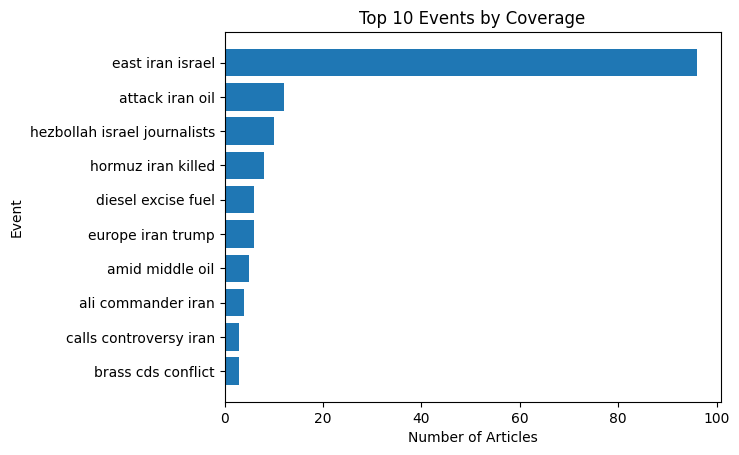

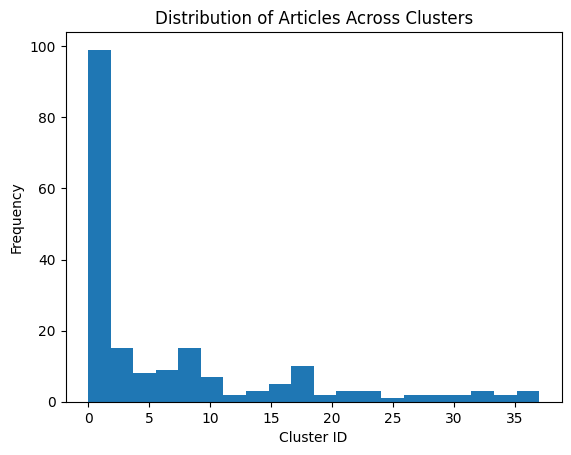

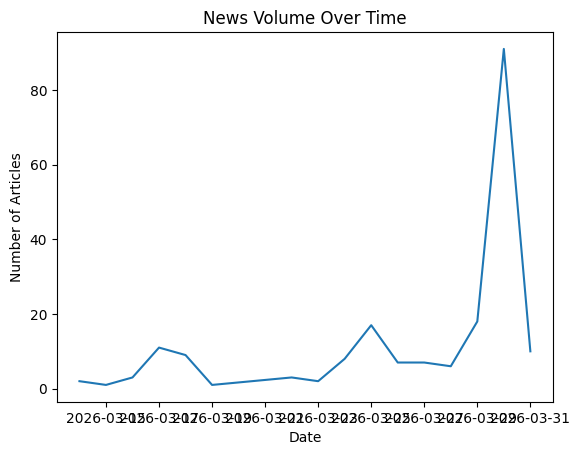

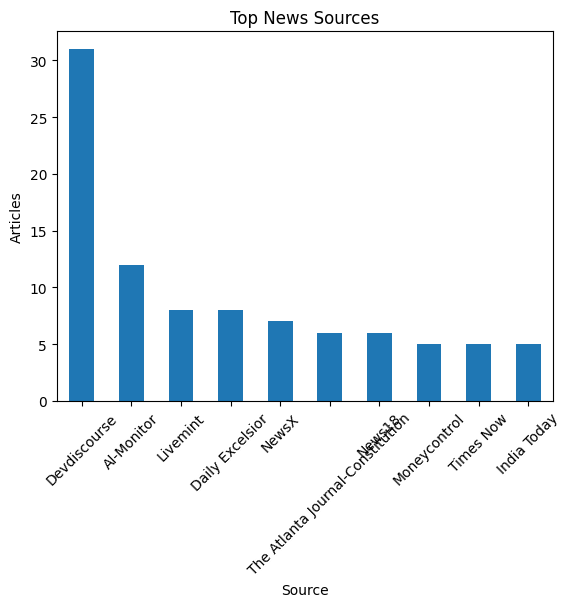

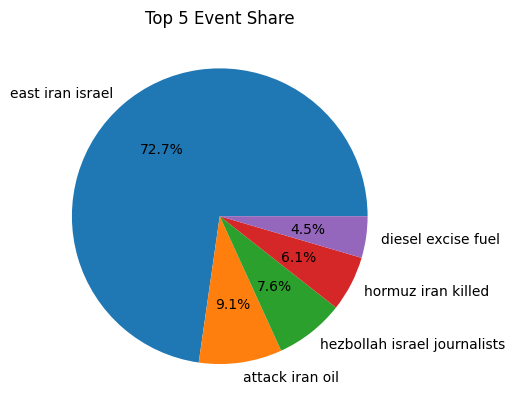

In [12]:
import matplotlib.pyplot as plt

top_events = events_ranked.head(10)

plt.figure()
plt.barh(top_events["event_name"], top_events["count"])
plt.xlabel("Number of Articles")
plt.ylabel("Event")
plt.title("Top 10 Events by Coverage")
plt.gca().invert_yaxis()
plt.show()
plt.figure()
plt.hist(df["cluster"], bins=20)
plt.xlabel("Cluster ID")
plt.ylabel("Frequency")
plt.title("Distribution of Articles Across Clusters")
plt.show()
events_per_day = df.groupby("date_only").size()

plt.figure()
events_per_day.plot()
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.title("News Volume Over Time")
plt.show()

source_counts = df["source"].value_counts().head(10)

plt.figure()
source_counts.plot(kind="bar")
plt.xlabel("Source")
plt.ylabel("Articles")
plt.title("Top News Sources")
plt.xticks(rotation=45)
plt.show()


top5 = events_ranked.head(5)

plt.figure()
plt.pie(top5["count"], labels=top5["event_name"], autopct='%1.1f%%')
plt.title("Top 5 Event Share")
plt.show()

import plotly.express as px

fig = px.bar(
    events_ranked.head(10),
    x="count",
    y="event_name",
    orientation='h',
    title="Top Events (Interactive)"
)

fig.show()

In [35]:
# ==============================
#Clickbait detection(Headline)
# ==============================

import pandas as pd
import torch
from transformers import pipeline

#Load Data
df = df1.copy()
df = df.dropna(subset=["headline"])
df.reset_index(drop=True, inplace=True)

print("Dataset size:", len(df))


#Load model
classifier = pipeline(
    "text-classification",
    model="textattack/bert-base-uncased-yelp-polarity",  #BERT trained on Yelp sentiment
    device=0 if torch.cuda.is_available() else -1
)


#Prediction
def detect_clickbait(texts, batch_size=16):
    results = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        preds = classifier(batch)

        for p in preds:
            results.append({
                "label": p["label"],
                "score": p["score"]
            })

    return results


predictions = detect_clickbait(df["headline"].tolist())

df["raw_label"] = [p["label"] for p in predictions]
df["clickbait_prob"] = [round(p["score"], 3) for p in predictions]

#Heuristic mapping
df["is_clickbait"] = df["raw_label"] == "LABEL_1"


#Output
print("\nClickbait distribution:")
print(df["is_clickbait"].value_counts())

print("\n SAMPLE OUTPUT:\n")

for _, row in df.head(10).iterrows():
    print("==============================")
    print("Headline:", row["headline"])
    print("Label:", row["raw_label"])
    print("Confidence:", row["clickbait_prob"])
    print("Clickbait:", row["is_clickbait"])

Dataset size: 196


config.json:   0%|          | 0.00/520 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


Clickbait distribution:
is_clickbait
False    105
True      91
Name: count, dtype: int64

 SAMPLE OUTPUT:

Headline: Turkey's Neutral Stance in Middle East Tensions: Fidan's Diplomatic Mission
Label: LABEL_1
Confidence: 0.612
Clickbait: True
Headline: US-Israel vs Iran is not World War III, but the past could hold keys to the conflict’s future
Label: LABEL_0
Confidence: 0.581
Clickbait: False
Headline: Oscars 2026: 6 major political statements in the past at Academy Awards; Gaza, Israel-Palestine, ICE, racism
Label: LABEL_0
Confidence: 1.0
Clickbait: False
Headline: Escalating Tensions: Rising Death Toll in Gaza and West Bank Amid Israeli Strikes
Label: LABEL_1
Confidence: 0.733
Clickbait: True
Headline: War rages on multiple fronts as Israeli attacks in Lebanon grow, Iran shipping stranglehold persists
Label: LABEL_1
Confidence: 0.902
Clickbait: True
Headline: Drone attack sparks fuel tank blaze at Dubai International Airport as flights reroute amid US-Iran war
Label: LABEL_0
Confide

In [37]:
# ==============================
#Clickbait detection(Headline+Content)
# ==============================

#Load Data
df = df1.copy()
df = df.dropna(subset=["headline", "content"])
df.reset_index(drop=True, inplace=True)

print("Dataset size:", len(df))

#Used only first 300 chars of content to avoid overflow
df["text"] = df["headline"] + " " + df["content"].str[:300]


#Load model
classifier = pipeline(
    "text-classification",
    model="textattack/bert-base-uncased-yelp-polarity",
    device=0 if torch.cuda.is_available() else -1
)


#Prediction
def detect_clickbait(texts, batch_size=16):
    results = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]

        preds = classifier(
            batch,
            truncation=True,   #Prevents token overflow
            max_length=512
        )

        for p in preds:
            results.append({
                "label": p["label"],
                "score": p["score"]
            })

    return results


#Run prediction
predictions = detect_clickbait(df["text"].tolist())

df["raw_label"] = [p["label"] for p in predictions]
df["clickbait_prob"] = [round(p["score"], 3) for p in predictions]

#Heuristic mapping(LABEL_1 is clickbait)
df["is_clickbait"] = df["raw_label"] == "LABEL_1"


#Output
print("\nClickbait distribution:")
print(df["is_clickbait"].value_counts())

print("\n SAMPLE OUTPUT:\n")

for _, row in df.head(10).iterrows():
    print("==============================")
    print("Headline:", row["headline"])
    print("Text (short):", row["text"][:100])
    print("Label:", row["raw_label"])
    print("Confidence:", row["clickbait_prob"])
    print("Clickbait:", row["is_clickbait"])

Dataset size: 196


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Clickbait distribution:
is_clickbait
False    140
True      56
Name: count, dtype: int64

 SAMPLE OUTPUT:

Headline: Turkey's Neutral Stance in Middle East Tensions: Fidan's Diplomatic Mission
Text (short): Turkey's Neutral Stance in Middle East Tensions: Fidan's Diplomatic Mission Turkey's Neutral Stance 
Label: LABEL_0
Confidence: 0.977
Clickbait: False
Headline: US-Israel vs Iran is not World War III, but the past could hold keys to the conflict’s future
Text (short): US-Israel vs Iran is not World War III, but the past could hold keys to the conflict’s future <HTML>
Label: LABEL_0
Confidence: 1.0
Clickbait: False
Headline: Oscars 2026: 6 major political statements in the past at Academy Awards; Gaza, Israel-Palestine, ICE, racism
Text (short): Oscars 2026: 6 major political statements in the past at Academy Awards; Gaza, Israel-Palestine, ICE
Label: LABEL_0
Confidence: 0.999
Clickbait: False
Headline: Escalating Tensions: Rising Death Toll in Gaza and West Bank Amid Israeli Strike

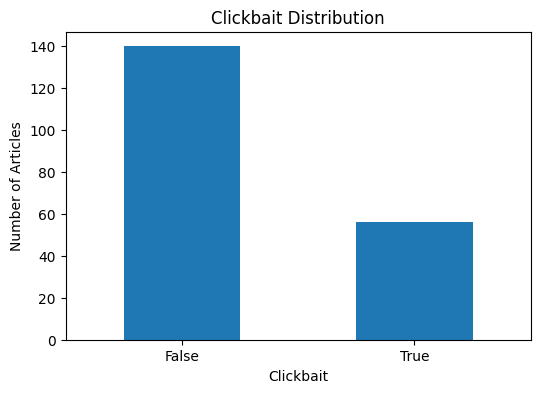

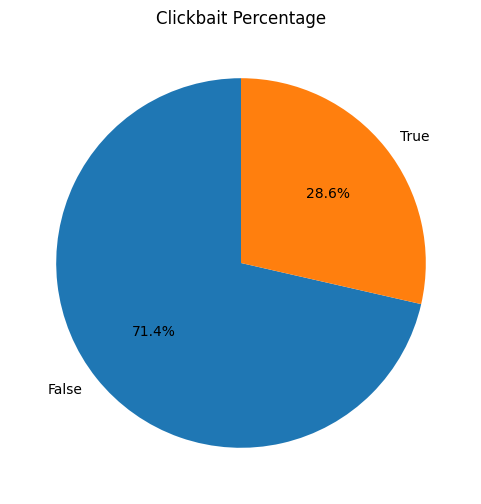

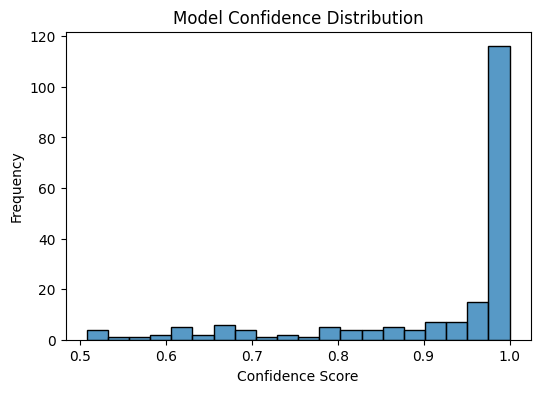

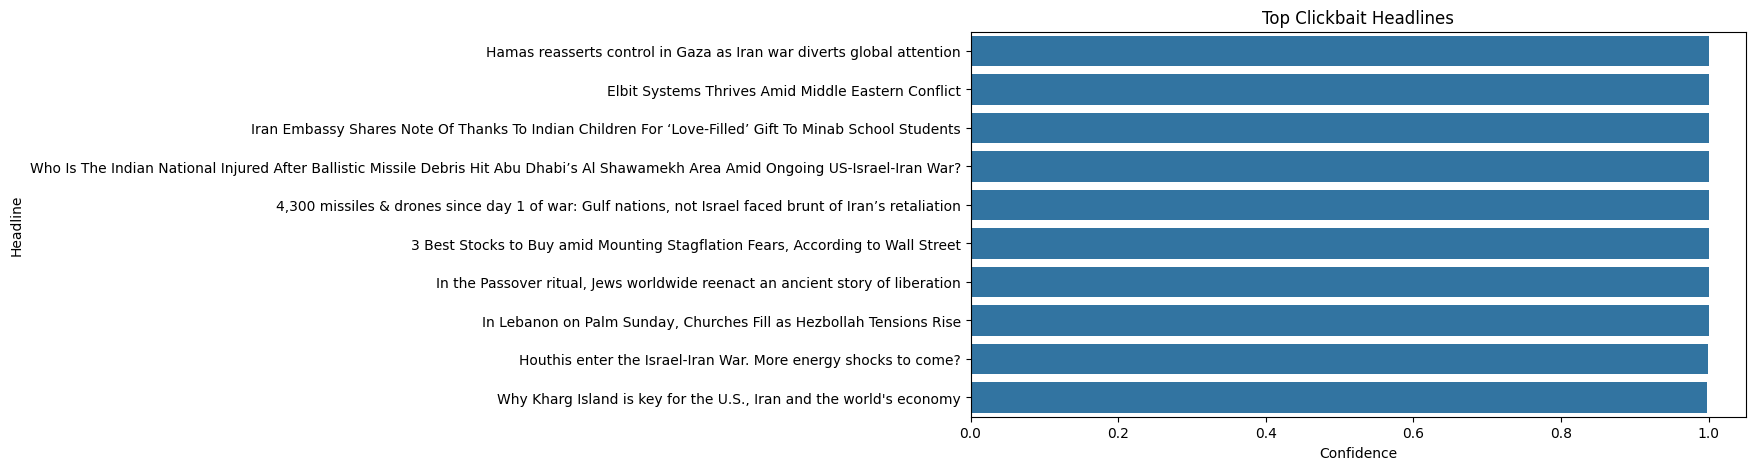

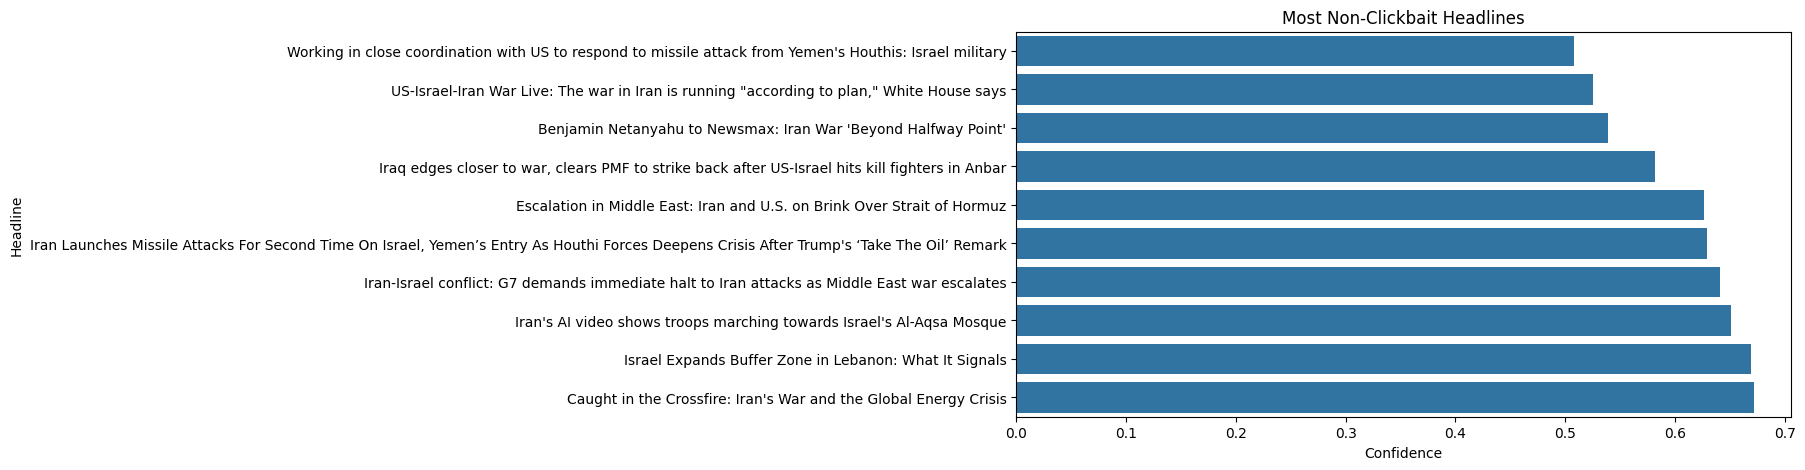

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

#Overall distribution of clickbait vs non-clickbait

plt.figure(figsize=(6,4))

df["is_clickbait"].value_counts().plot(
    kind="bar",
    title="Clickbait Distribution"
)

plt.xticks(rotation=0)
plt.xlabel("Clickbait")
plt.ylabel("Number of Articles")
plt.show()


#Percentage share
plt.figure(figsize=(6,6))

df["is_clickbait"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Clickbait Percentage")
plt.ylabel("")
plt.show()


#How confident the model is across all predictions
plt.figure(figsize=(6,4))

sns.histplot(df["clickbait_prob"], bins=20)

plt.title("Model Confidence Distribution")
plt.xlabel("Confidence Score")
plt.ylabel("Frequency")
plt.show()


#Most obvious clickbait headlines (highest confidence)

top_cb = df[df["is_clickbait"] == True] \
            .sort_values(by="clickbait_prob", ascending=False) \
            .head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_cb["clickbait_prob"],
    y=top_cb["headline"]
)

plt.title("Top Clickbait Headlines")
plt.xlabel("Confidence")
plt.ylabel("Headline")
plt.show()



#Most clearly non-clickbait headlines(lowest confidence)

top_non = df[df["is_clickbait"] == False] \
            .sort_values(by="clickbait_prob", ascending=True) \
            .head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_non["clickbait_prob"],
    y=top_non["headline"]
)

plt.title("Most Non-Clickbait Headlines")
plt.xlabel("Confidence")
plt.ylabel("Headline")
plt.show()

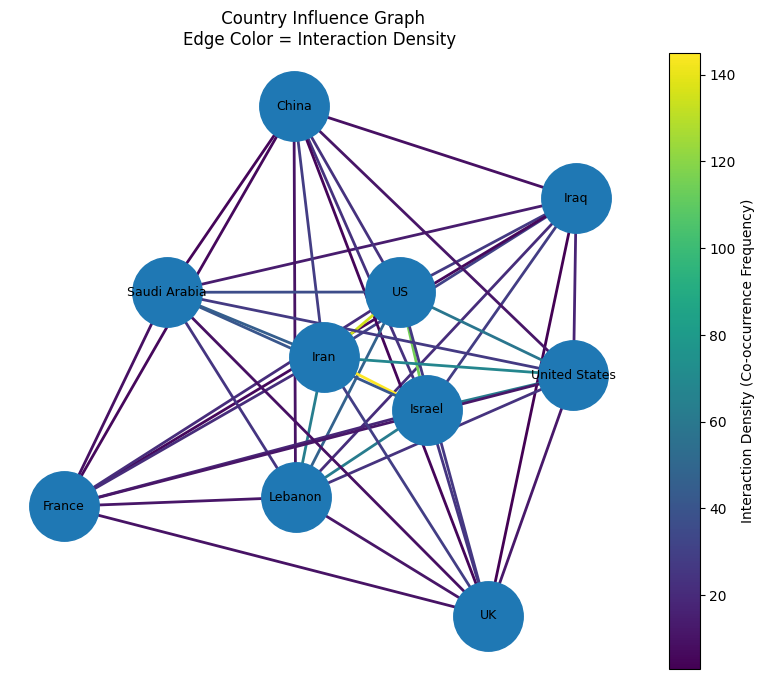

In [14]:
# ==============================
#Country graph
# ==============================

import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
import matplotlib.cm as cm
import numpy as np

#Country list
country_list = [
    "United States", "US", "USA", "India", "China", "Russia",
    "Iran", "Israel", "Pakistan", "Ukraine", "France", "Germany",
    "UK", "United Kingdom", "Saudi Arabia", "UAE", "Iraq",
    "Turkey", "Qatar", "Kuwait", "Lebanon", "Afghanistan"
]

def extract_countries(actor_list):
    countries = []
    for actor in actor_list:
        for country in country_list:
            if country.lower() in actor.lower():
                countries.append(country)
    return list(set(countries))

df["countries"] = df["actors"].apply(extract_countries)


#Build graph
G = nx.Graph()

for countries in df["countries"]:
    if len(countries) < 2:
        continue

    for c1, c2 in combinations(countries, 2):
        if G.has_edge(c1, c2):
            G[c1][c2]["weight"] += 1
        else:
            G.add_edge(c1, c2, weight=1)


#Top countries
centrality = nx.degree_centrality(G)            #Degree Centrality measures how connected each country is
top_countries = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:10]       #Sort by importance

sub_nodes = [c for c, _ in top_countries]
subG = G.subgraph(sub_nodes)


#Top colors
weights = [d["weight"] for (_, _, d) in subG.edges(data=True)]

norm = plt.Normalize(min(weights), max(weights))        #Normalize weights
cmap = cm.viridis
edge_colors = cmap(norm(weights))


#Visualize
fig, ax = plt.subplots(figsize=(10, 8))

pos = nx.spring_layout(subG, seed=42)

nx.draw(
    subG,
    pos,
    ax=ax,
    with_labels=True,
    node_size=2500,
    font_size=9,
    edge_color=edge_colors,
    width=2
)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Interaction Density (Co-occurrence Frequency)")

ax.set_title(" Country Influence Graph\nEdge Color = Interaction Density")

plt.show()

In [15]:
df.to_csv("final_data.csv", index=False)
events_ranked.to_csv("events_ranked.csv", index=False)

In [16]:
# ==============================
#Risk model
# ==============================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

#Load
df = df1.copy()

# Clean
df = df.dropna(subset=["headline"])
df.reset_index(drop=True, inplace=True)

#Create risk score
risk_keywords = {
    "war": 3,
    "missile": 3,
    "attack": 2.5,
    "strike": 2.5,
    "conflict": 2,
    "tension": 1.5,
    "threat": 2,
    "explosion": 3,
    "military": 1.5
}

def keyword_score(text):
    text = str(text).lower()
    score = 0
    for word, weight in risk_keywords.items():
        if word in text:
            score += weight
    return score

df["risk_score"] = df["headline"].apply(keyword_score)

# Normalize
df["risk_score"] = (df["risk_score"] / (df["risk_score"].max() + 1e-5)) * 10

#Create lebel
def risk_label(score):
    if score >= 4:
        return "MEDIUM"
    else:
        return "LOW"

df["risk_level"] = df["risk_score"].apply(risk_label)

print("\nClass distribution:\n", df["risk_level"].value_counts())

#Model
X = df["headline"]
y = df["risk_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
#Removes common words and keep top 3000 features
vectorizer = TfidfVectorizer(stop_words="english", max_features=3000)
#Converts text to numerical matrix
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

#Logistic Regression
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_vec, y_train)

#Evaluaate
y_pred = model.predict(X_test_vec)

print("\n MODEL PERFORMANCE:\n")
print(classification_report(y_test, y_pred))

#Feature Importance
feature_names = vectorizer.get_feature_names_out()
#Each word has a weight
coefficients = model.coef_[0]
#Negative weights to push toward low risk
top_positive = sorted(zip(coefficients, feature_names), reverse=True)[:10]
top_negative = sorted(zip(coefficients, feature_names))[:10]

print("\n Words indicating HIGHER risk:\n")
for coef, word in top_positive:
    print(word, ":", round(coef, 3))

print("\n Words indicating LOWER risk:\n")
for coef, word in top_negative:
    print(word, ":", round(coef, 3))

#Sample Predictions
print("\n SAMPLE PREDICTIONS:\n")

for i in range(5):
    print("Headline:", X_test.iloc[i])
    print("Actual:", y_test.iloc[i])
    print("Predicted:", y_pred[i])
    print("------")


Class distribution:
 risk_level
LOW       159
MEDIUM     37
Name: count, dtype: int64

 MODEL PERFORMANCE:

              precision    recall  f1-score   support

         LOW       0.94      0.94      0.94        32
      MEDIUM       0.75      0.75      0.75         8

    accuracy                           0.90        40
   macro avg       0.84      0.84      0.84        40
weighted avg       0.90      0.90      0.90        40


 Words indicating HIGHER risk:

missile : 1.6
attacks : 1.271
drone : 1.086
updates : 0.953
live : 0.924
strikes : 0.856
houthi : 0.848
attack : 0.837
conflict : 0.713
yemen : 0.686

 Words indicating LOWER risk:

escalating : -0.572
talks : -0.445
hormuz : -0.366
crisis : -0.346
gaza : -0.345
tensions : -0.333
says : -0.33
end : -0.33
strait : -0.325
airspace : -0.3

 SAMPLE PREDICTIONS:

Headline: 'Like a 6-year-old': Emmy Award-winning host blasts Trump’s word games over Iran 'war'
Actual: LOW
Predicted: LOW
------
Headline: Higher airfares due to any fu